# Figure 3: Dynamics of decision parameters across action costs.

## setup and imports

In [1]:
import fnmatch
import matplotlib.pyplot as plt
import numpy as np
import glob

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [2]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [3]:
rat_markers = {}
sequence = {}

# INTACT RATS
animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']


m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in animalList if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in animalList if 'F' in x]), start_intensity=80)

for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    # define marker and color for each rat, used in plots
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

Loading data for RatF00
Loading data for RatF01
Loading data for RatF02
Loading data for RatM00
Loading data for RatM01
Loading data for RatM02
Loading data for RatF32
Loading data for RatF33
Loading data for RatM31
Loading data for RatM32
Loading data for RatF42
Loading data for RatM40
Loading data for RatM43
Loading data for RatM53
Loading data for RatM54


# Figure 3A Schematics of three action cost conditions with increasing platform distances.
# Figure 3D Same with treadmill velocity.

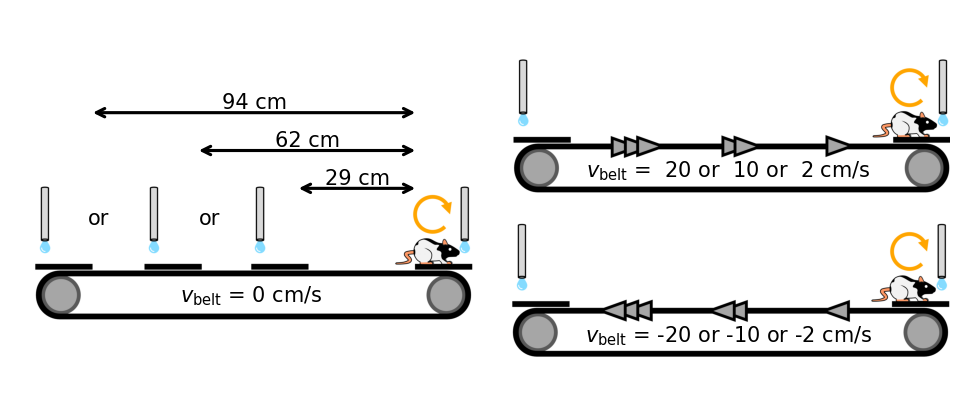

In [4]:
def Figure3A(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Aidle.png"

    img = plt.imread(path)
    img = img[300:2600, 150:3075]
    img = np.concatenate((np.ones((300, img.shape[1], 3), dtype=np.uint8), img), axis=0)
    
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ = 0 cm/s', x=img.shape[1]/2, y=1760, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=450, y=1250, ha="center", va="center", fontsize=5)
    ax.text(s='or', x=1185, y=1250, ha="center", va="center", fontsize=5)

    ax.annotate(text='', xy=(1720, 1050), xytext=(2600, 1050), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(1060, 800), xytext=(2600, 800), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    ax.annotate(text='', xy=(360, 550), xytext=(2600, 550), arrowprops=dict(arrowstyle='<->', lw=0.75), fontsize=5, zorder=5)
    
    ax.annotate(text='29 cm', xy=(0, 0), xytext=((1720+2600)/2, 1050), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='62 cm', xy=(0, 0), xytext=((1060+2600)/2, 800), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)
    ax.annotate(text='94 cm', xy=(0, 0), xytext=((360+2600)/2, 550), ha='center', va='bottom', xycoords='data', fontsize=5, zorder=5)

def Figure3D(ax=None, path=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    if path is None:
        path = "./Figures/3Didle.png"

    img = plt.imread(path)
    img = img[:, 150:3075]
    ax.imshow(img)
    ax.axis("off")
    ax.text(s=r'$v_{\mathrm{belt}}$ =  20 or  10 or  2 cm/s', x=img.shape[1]/2, y=930, ha="center", va="center", fontsize=5)
    ax.text(s=r'$v_{\mathrm{belt}}$ = -20 or -10 or -2 cm/s', x=img.shape[1]/2, y=2020, ha="center", va="center", fontsize=5)

fig, axs = plt.subplots(1, 2, figsize=(cm2inch(8), cm2inch(4)))
Figure3A(ax=axs[0])
Figure3D(ax=axs[1])

# 3B Effect of distance on α0, αt and αu
# 3C Effect of distance on γ0, γt and γu

$\alpha_0$: p_s=1.000, p_i=0.000, obs_slope=0.008, obs_intercept=1.153
$\alpha_t$: p_s=0.000, p_i=0.000, obs_slope=-0.022, obs_intercept=0.194
$\alpha_u$: p_s=0.400, p_i=0.500, obs_slope=0.017, obs_intercept=-0.013
$\gamma_0$: p_s=0.900, p_i=0.000, obs_slope=-0.011, obs_intercept=0.739
$\gamma_t$: p_s=0.700, p_i=0.000, obs_slope=0.002, obs_intercept=-0.046
$\gamma_u$: p_s=0.800, p_i=0.000, obs_slope=0.002, obs_intercept=-0.156
$\mu_0$: p_s=0.000, p_i=0.000, obs_slope=0.266, obs_intercept=0.864
$\mu_t$: p_s=0.000, p_i=0.000, obs_slope=0.009, obs_intercept=0.052
$\mu_u$: p_s=0.600, p_i=0.200, obs_slope=-0.004, obs_intercept=0.012
$\sigma_0$: p_s=0.200, p_i=0.000, obs_slope=0.006, obs_intercept=0.083
$\sigma_t$: p_s=1.000, p_i=0.000, obs_slope=0.000, obs_intercept=0.006
$\sigma_u$: p_s=0.200, p_i=0.000, obs_slope=0.004, obs_intercept=0.021
$\alpha_0$: p_s=0.700, p_i=0.000, obs_slope=0.006, obs_intercept=1.535
$\alpha_t$: p_s=0.000, p_i=0.000, obs_slope=0.010, obs_intercept=0.149
$\alpha_u

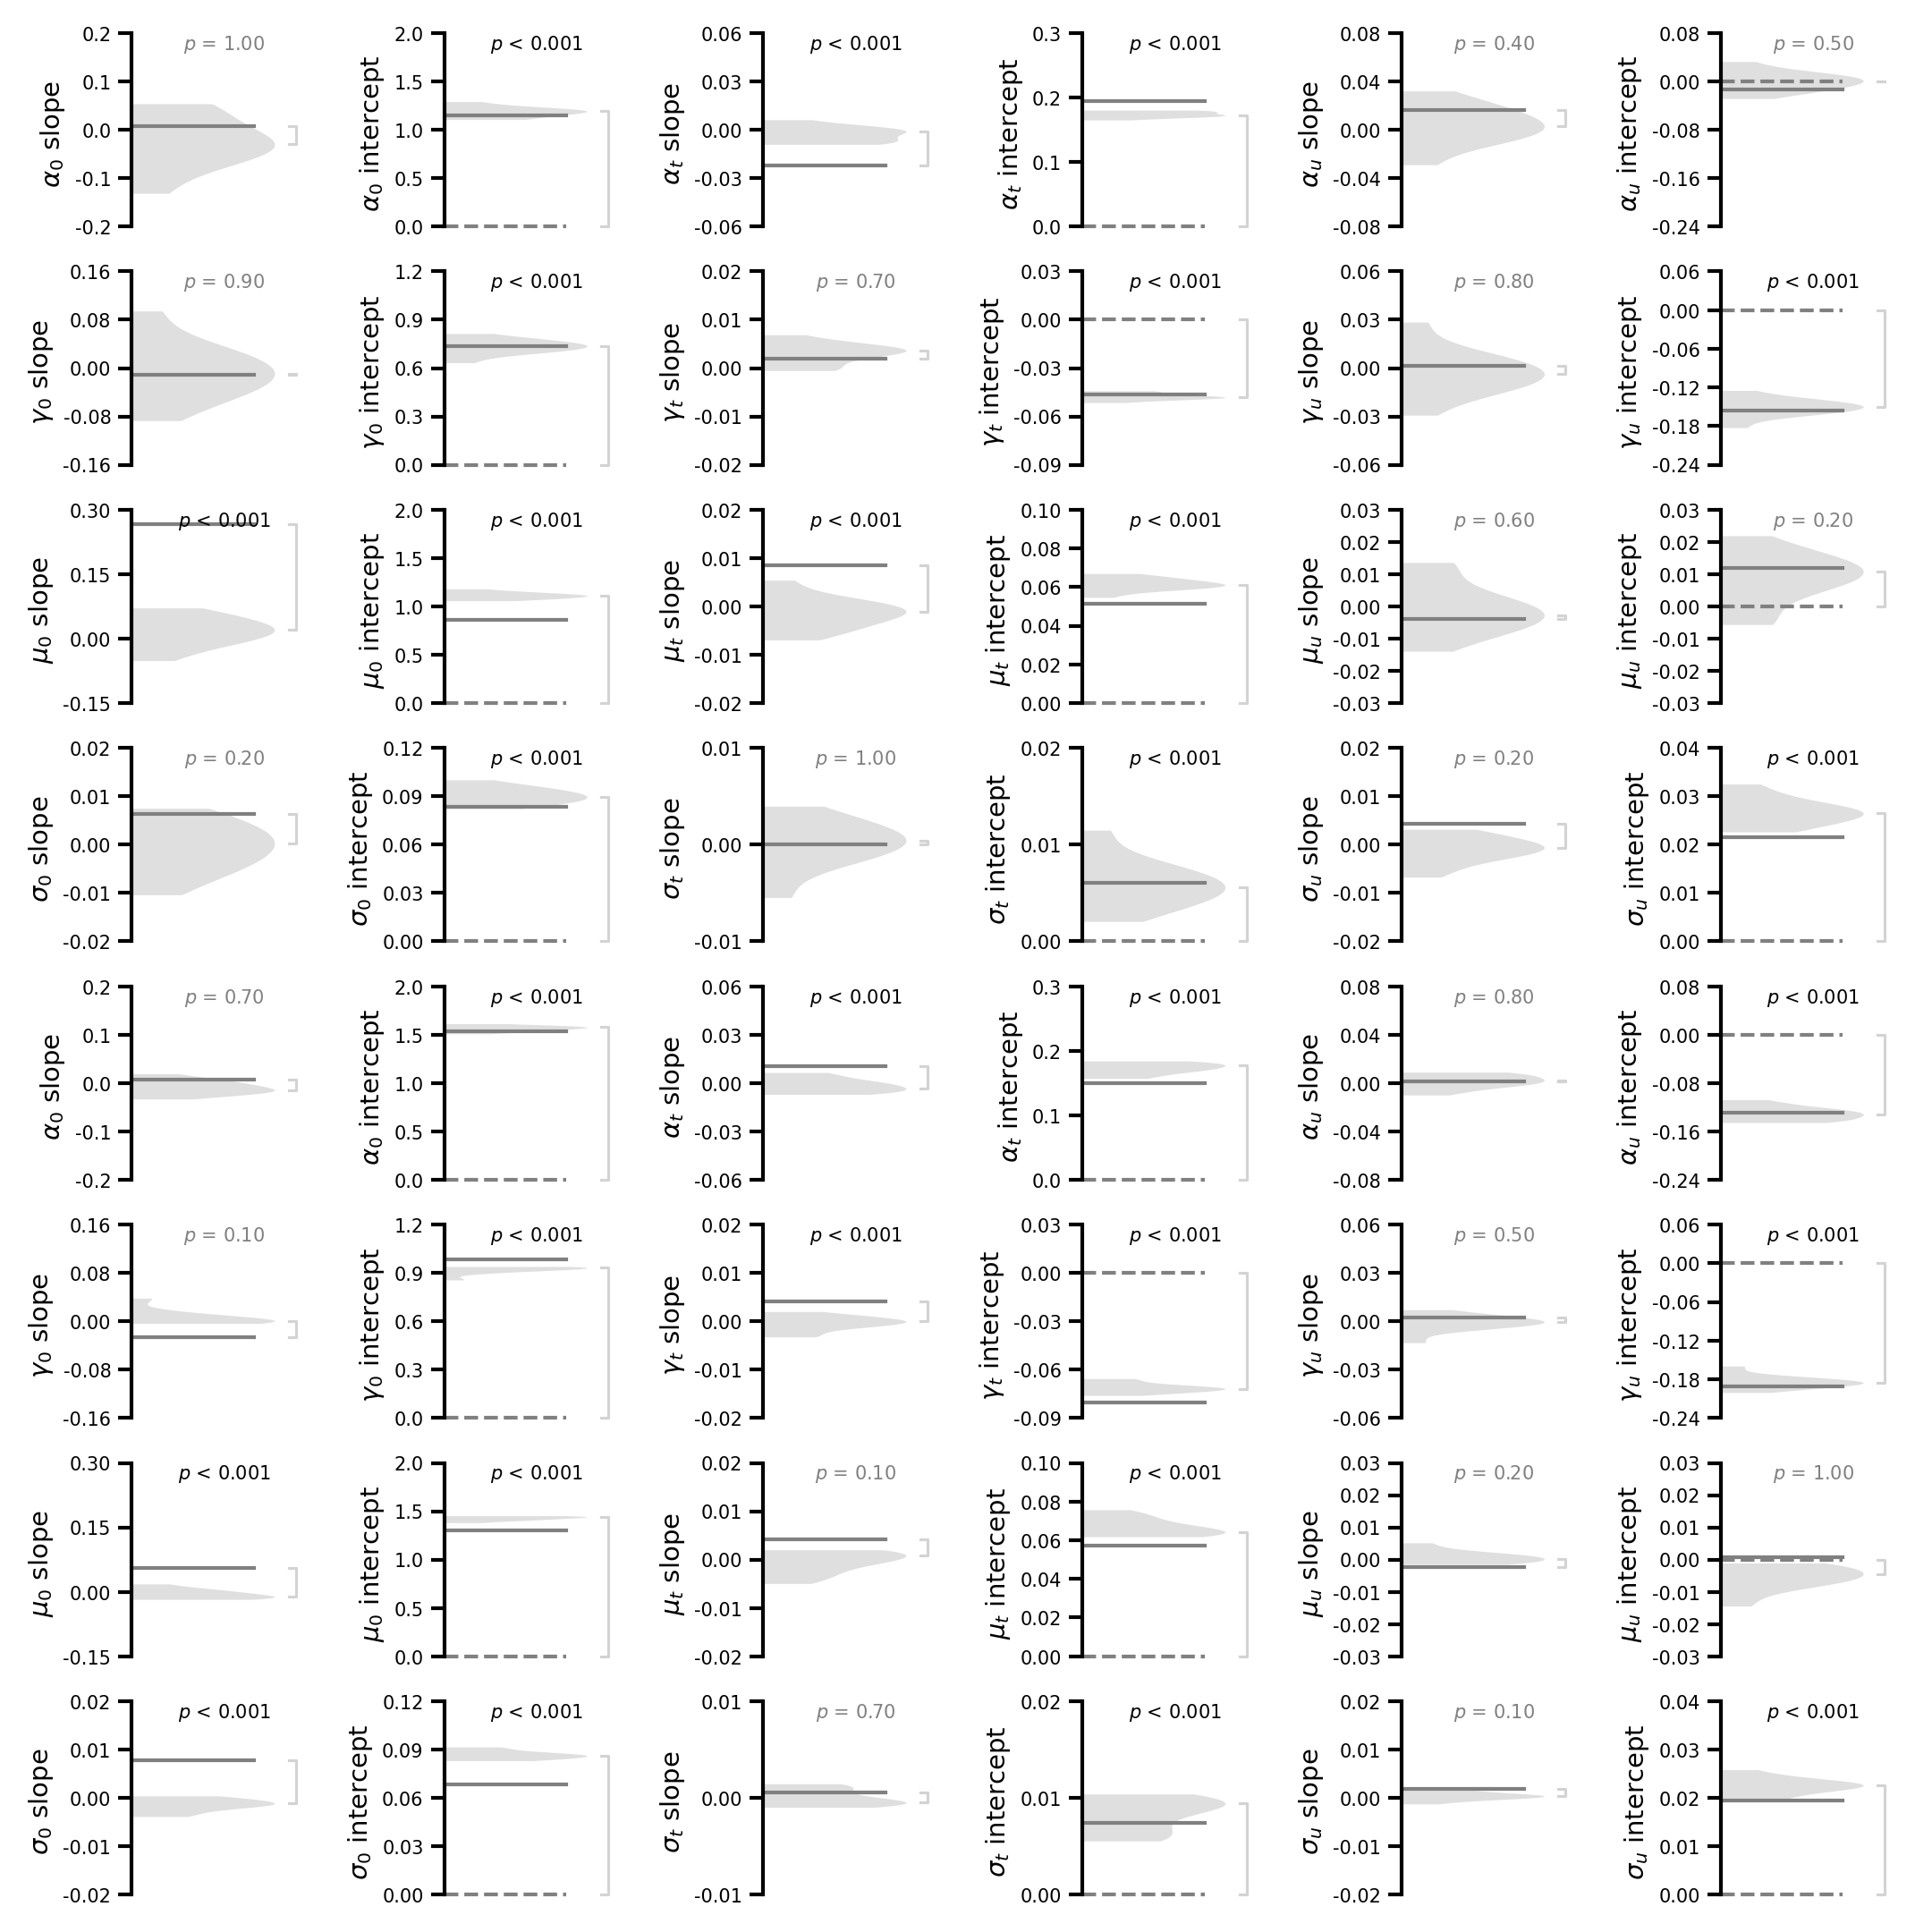

In [5]:
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

PLOT_PARAMS = {
    'alpha_0':  dict(fit=alpha_0, yticks_slope=[-0.2, -0.1, 0, 0.1, 0.2], yticks_intercept=[0, .5, 1, 1.5, 2], ylabel=r'$\alpha_0$'),
    'alpha_t':  dict(fit=alpha_t, yticks_slope=[-.06, -.03, 0, .03, .06], yticks_intercept=[0, .1, .2, .3], ylabel=r'$\alpha_t$'),
    'alpha_u':  dict(fit=alpha_u, yticks_slope=[-.08, -.04, 0, .04, .08], yticks_intercept=[-.24, -.16, -.08, 0, .08], ylabel=r'$\alpha_u$'),
    'gamma_0':  dict(fit=gamma_0, yticks_slope=[-.16, -.08, 0, .08, .16], yticks_intercept=[0, .3, .6, .9, 1.2], ylabel=r'$\gamma_0$'),
    'gamma_t':  dict(fit=gamma_t, yticks_slope=[-.02, -.01, 0, .01, .02], yticks_intercept=[-.09, -.06, -.03, 0, 0.03], ylabel=r'$\gamma_t$'),
    'gamma_u':  dict(fit=gamma_u, yticks_slope=[-.06, -.03, 0, .03, .06], yticks_intercept=[-.24, -.18, -.12, -0.06, 0, 0.06], ylabel=r'$\gamma_u$'),
    'mu_0':     dict(fit=mu_0, yticks_slope=[-0.15, 0, 0.15, 0.3], yticks_intercept=[0, .5, 1, 1.5, 2], ylabel=r'$\mu_0$'),
    'mu_t':     dict(fit=mu_t, yticks_slope=[-.02, -.01, 0, .01, .02], yticks_intercept=[0, .02, .04, .06, .08, .1], ylabel=r'$\mu_t$'),
    'mu_u':     dict(fit=mu_u, yticks_slope=[-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03], yticks_intercept=[-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03], ylabel=r'$\mu_u$'),
    'sigma_0':  dict(fit=sigma_0, yticks_slope=[-0.02, -0.01, 0, 0.01, 0.02], yticks_intercept=[0, .03, 0.06, .09, .12], ylabel=r'$\sigma_0$'),
    'sigma_t':  dict(fit=sigma_t, yticks_slope=[-.01, 0, .01], yticks_intercept=[0, .01, .02], ylabel=r'$\sigma_t$'),
    'sigma_u':  dict(fit=sigma_u, yticks_slope=[-0.02, -0.01, 0, 0.01, 0.02], yticks_intercept=[0, 0.01, 0.02, 0.03, 0.04], ylabel=r'$\sigma_u$'),
}

def plot_stats(param_name, dist_or_tm='dist', ax_slope=None, ax_intercept=None):
    if ax_slope is None or ax_intercept is None:
        _, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(10, 5))

    params = PLOT_PARAMS[param_name]
    
    regression_permutation(params['fit'], dist_or_tm=dist_or_tm, varname=params['ylabel'], 
                        ax_slope=ax_slope, yticks_slope=params['yticks_slope'], 
                        ax_intercept=ax_intercept, y_ticks_intercept=params['yticks_intercept'], num_iterations=10)

fig, axs = plt.subplots(8, 6, figsize=(cm2inch(18), cm2inch(18)))

plot_stats('alpha_0', dist_or_tm='dist', ax_slope=axs[0, 0], ax_intercept=axs[0, 1])
plot_stats('alpha_t', dist_or_tm='dist', ax_slope=axs[0, 2], ax_intercept=axs[0, 3])
plot_stats('alpha_u', dist_or_tm='dist', ax_slope=axs[0, 4], ax_intercept=axs[0, 5])
plot_stats('gamma_0', dist_or_tm='dist', ax_slope=axs[1, 0], ax_intercept=axs[1, 1])
plot_stats('gamma_t', dist_or_tm='dist', ax_slope=axs[1, 2], ax_intercept=axs[1, 3])
plot_stats('gamma_u', dist_or_tm='dist', ax_slope=axs[1, 4], ax_intercept=axs[1, 5])
plot_stats('mu_0', dist_or_tm='dist', ax_slope=axs[2, 0], ax_intercept=axs[2, 1])
plot_stats('mu_t', dist_or_tm='dist', ax_slope=axs[2, 2], ax_intercept=axs[2, 3])
plot_stats('mu_u', dist_or_tm='dist', ax_slope=axs[2, 4], ax_intercept=axs[2, 5])
plot_stats('sigma_0', dist_or_tm='dist', ax_slope=axs[3, 0], ax_intercept=axs[3, 1])
plot_stats('sigma_t', dist_or_tm='dist', ax_slope=axs[3, 2], ax_intercept=axs[3, 3])
plot_stats('sigma_u', dist_or_tm='dist', ax_slope=axs[3, 4], ax_intercept=axs[3, 5])



plot_stats('alpha_0', dist_or_tm='tm', ax_slope=axs[4, 0], ax_intercept=axs[4, 1])
plot_stats('alpha_t', dist_or_tm='tm', ax_slope=axs[4, 2], ax_intercept=axs[4, 3])
plot_stats('alpha_u', dist_or_tm='tm', ax_slope=axs[4, 4], ax_intercept=axs[4, 5])
plot_stats('gamma_0', dist_or_tm='tm', ax_slope=axs[5, 0], ax_intercept=axs[5, 1])
plot_stats('gamma_t', dist_or_tm='tm', ax_slope=axs[5, 2], ax_intercept=axs[5, 3])
plot_stats('gamma_u', dist_or_tm='tm', ax_slope=axs[5, 4], ax_intercept=axs[5, 5])
plot_stats('mu_0', dist_or_tm='tm', ax_slope=axs[6, 0], ax_intercept=axs[6, 1])
plot_stats('mu_t', dist_or_tm='tm', ax_slope=axs[6, 2], ax_intercept=axs[6, 3])
plot_stats('mu_u', dist_or_tm='tm', ax_slope=axs[6, 4], ax_intercept=axs[6, 5])
plot_stats('sigma_0', dist_or_tm='tm', ax_slope=axs[7, 0], ax_intercept=axs[7, 1])
plot_stats('sigma_t', dist_or_tm='tm', ax_slope=axs[7, 2], ax_intercept=axs[7, 3])
plot_stats('sigma_u', dist_or_tm='tm', ax_slope=axs[7, 4], ax_intercept=axs[7, 5])

In [6]:



def _regression_permutation(var, dist_or_tm='dist', lesioned_animals=False, num_iterations=10000):
    ''' regression with permutation test for the slope and intercept
    var: parameter to test (e.g., alpha_0)
    dist_or_tm: 'dist' or 'tm'
    varname: name of the parameter
    lesioned_animals: True or False
    raisy: y position of the p-value
    ax_slope: axes object for the slope
    yticks_slope: yticks for the slope
    ax_intercept: axes object for the intercept
    y_ticks_intercept: yticks for the intercept
    '''
    # if ax_slope is None and ax_intercept is None:
    #     fig, (ax_slope, ax_intercept) = plt.subplots(1, 2, figsize=(4, 2))

    if lesioned_animals:
        color = 'xkcd:kiwi green'
        animalList = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
                    'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']
    else:
        color='gray'
        animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
                    'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']

    df = pd.DataFrame(columns=['animal', 'parameter', 'cond'])

    _ = {"60": 0, "90": 1, "120": 2, "20": 0, "10": 1, "2": 2, "rev10": 3, "rev20": 4}

    for animal in animalList:
        if dist_or_tm == 'dist':
            conds = ["60", "90", "120"]
        elif dist_or_tm == 'tm':
            conds = ["20", "10", "2", "rev10", "rev20"]
        else:
            raise ValueError("experiment must be 'dist' or 'tm'")
        for cond in conds:
            x = float(_[cond])
            y = var[animal][cond]
            df = df.append({"animal": animal, "parameter": y, 'cond': x}, ignore_index=True)

    x = df.cond
    y = df.parameter

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # shuffle to get p-value
    observed_slope = p[0]
    observed_intercept = p[1]
    slope_sign = np.sign(observed_slope)
    num_iterations = int(num_iterations)
    shuffled_slopes = []
    shuffled_intercepts = []

    np.random.seed(0)
    for _ in range(num_iterations):
        shuffled_y = np.random.permutation(y)
        shuffled_res, _ = curve_fit(f, x, shuffled_y, [1, 1])
        shuffled_slopes.append(shuffled_res[0])
        shuffled_intercepts.append(shuffled_res[1])

    # calculate the p-value
    p_value_slope = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()
    if observed_intercept >= 0:
        p_value_intercept = (np.asarray(shuffled_intercepts) <= 0).mean()
    else:
        p_value_intercept = (np.asarray(shuffled_intercepts) >= 0).mean()

    # compute r
    # y_mean = np.mean(y)
    # y_pred = f(x, *p)
    # ss_total = np.sum((y - y_mean) ** 2)
    # ss_res = np.sum((y - y_pred) ** 2)
    # r_squared = 1 - (ss_res / ss_total)
    # r = np.sqrt(r_squared)

    print(f'p_s={p_value_slope:.3f}, p_i={p_value_intercept:.3f}, obs_slope={observed_slope:.3f}, obs_intercept={observed_intercept:.3f}')
    # plot_shuffling(shuffles=shuffled_slopes, pval=p_value_slope, observed=observed_slope, yticks=yticks_slope, ylabel=f'{varname} slope', ax=ax_slope, color=color, raisy=raisy)
    # plot_shuffling(shuffles=shuffled_intercepts, pval=p_value_intercept, observed=observed_intercept, show_zero=True, yticks=y_ticks_intercept, ylabel=f'{varname} intercept', ax=ax_intercept, color=color)

    return shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept

shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = _regression_permutation(alpha_0, dist_or_tm='dist', lesioned_animals=False, num_iterations=100)

p_s=0.950, p_i=0.000, obs_slope=0.008, obs_intercept=1.153


In [7]:
dist_shuffled_slopes, dist_p_value_slope, dist_observed_slope = [], [], []
dist_shuffled_intercepts, dist_p_value_intercept, dist_observed_intercept = [], [], []
tm_shuffled_slopes, tm_p_value_slope, tm_observed_slope = [], [], []
tm_shuffled_intercepts, tm_p_value_intercept, tm_observed_intercept = [], [], []

vars = [alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u][::-1]
names = [param['ylabel'] for param in PLOT_PARAMS.values()][::-1]
for var in vars:
    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = _regression_permutation(var, dist_or_tm='dist', lesioned_animals=False, num_iterations=10000)

    dist_shuffled_slopes.append(shuffled_slopes)
    dist_p_value_slope.append(p_value_slope)
    dist_observed_slope.append(observed_slope)
    dist_shuffled_intercepts.append(shuffled_intercepts)
    dist_p_value_intercept.append(p_value_intercept)
    dist_observed_intercept.append(observed_intercept)

    shuffled_slopes, p_value_slope, observed_slope, shuffled_intercepts, p_value_intercept, observed_intercept = _regression_permutation(var, dist_or_tm='tm', lesioned_animals=False, num_iterations=10000)
    tm_shuffled_slopes.append(shuffled_slopes)
    tm_p_value_slope.append(p_value_slope)
    tm_observed_slope.append(observed_slope)
    tm_shuffled_intercepts.append(shuffled_intercepts)
    tm_p_value_intercept.append(p_value_intercept)
    tm_observed_intercept.append(observed_intercept)

p_s=0.162, p_i=0.000, obs_slope=0.004, obs_intercept=0.021
p_s=0.098, p_i=0.000, obs_slope=0.002, obs_intercept=0.020
p_s=0.993, p_i=0.004, obs_slope=0.000, obs_intercept=0.006
p_s=0.543, p_i=0.000, obs_slope=0.001, obs_intercept=0.007
p_s=0.212, p_i=0.000, obs_slope=0.006, obs_intercept=0.083
p_s=0.000, p_i=0.000, obs_slope=0.008, obs_intercept=0.068
p_s=0.595, p_i=0.128, obs_slope=-0.004, obs_intercept=0.012
p_s=0.426, p_i=0.745, obs_slope=-0.002, obs_intercept=0.001
p_s=0.112, p_i=0.000, obs_slope=0.009, obs_intercept=0.052
p_s=0.051, p_i=0.000, obs_slope=0.004, obs_intercept=0.057
p_s=0.000, p_i=0.000, obs_slope=0.266, obs_intercept=0.864
p_s=0.000, p_i=0.000, obs_slope=0.056, obs_intercept=1.306
p_s=0.923, p_i=0.000, obs_slope=0.002, obs_intercept=-0.156
p_s=0.760, p_i=0.000, obs_slope=0.002, obs_intercept=-0.191
p_s=0.654, p_i=0.000, obs_slope=0.002, obs_intercept=-0.046
p_s=0.092, p_i=0.000, obs_slope=0.004, obs_intercept=-0.080
p_s=0.839, p_i=0.000, obs_slope=-0.011, obs_interc

In [8]:
def bracket(ax, num1, num2, center, height, dh=.05, barh=.05):
    '''plot bracket between two points
    ax: axes object
    num1, num2: index of the two points
    center: x position of the two points
    height: y position of the two points
    dh: height of the bracket
    barh: height of the bar
    '''

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]
    y = max(ly, ry) + dh
    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    ax.plot(barx, bary, c='k', zorder=10, lw=0.75)

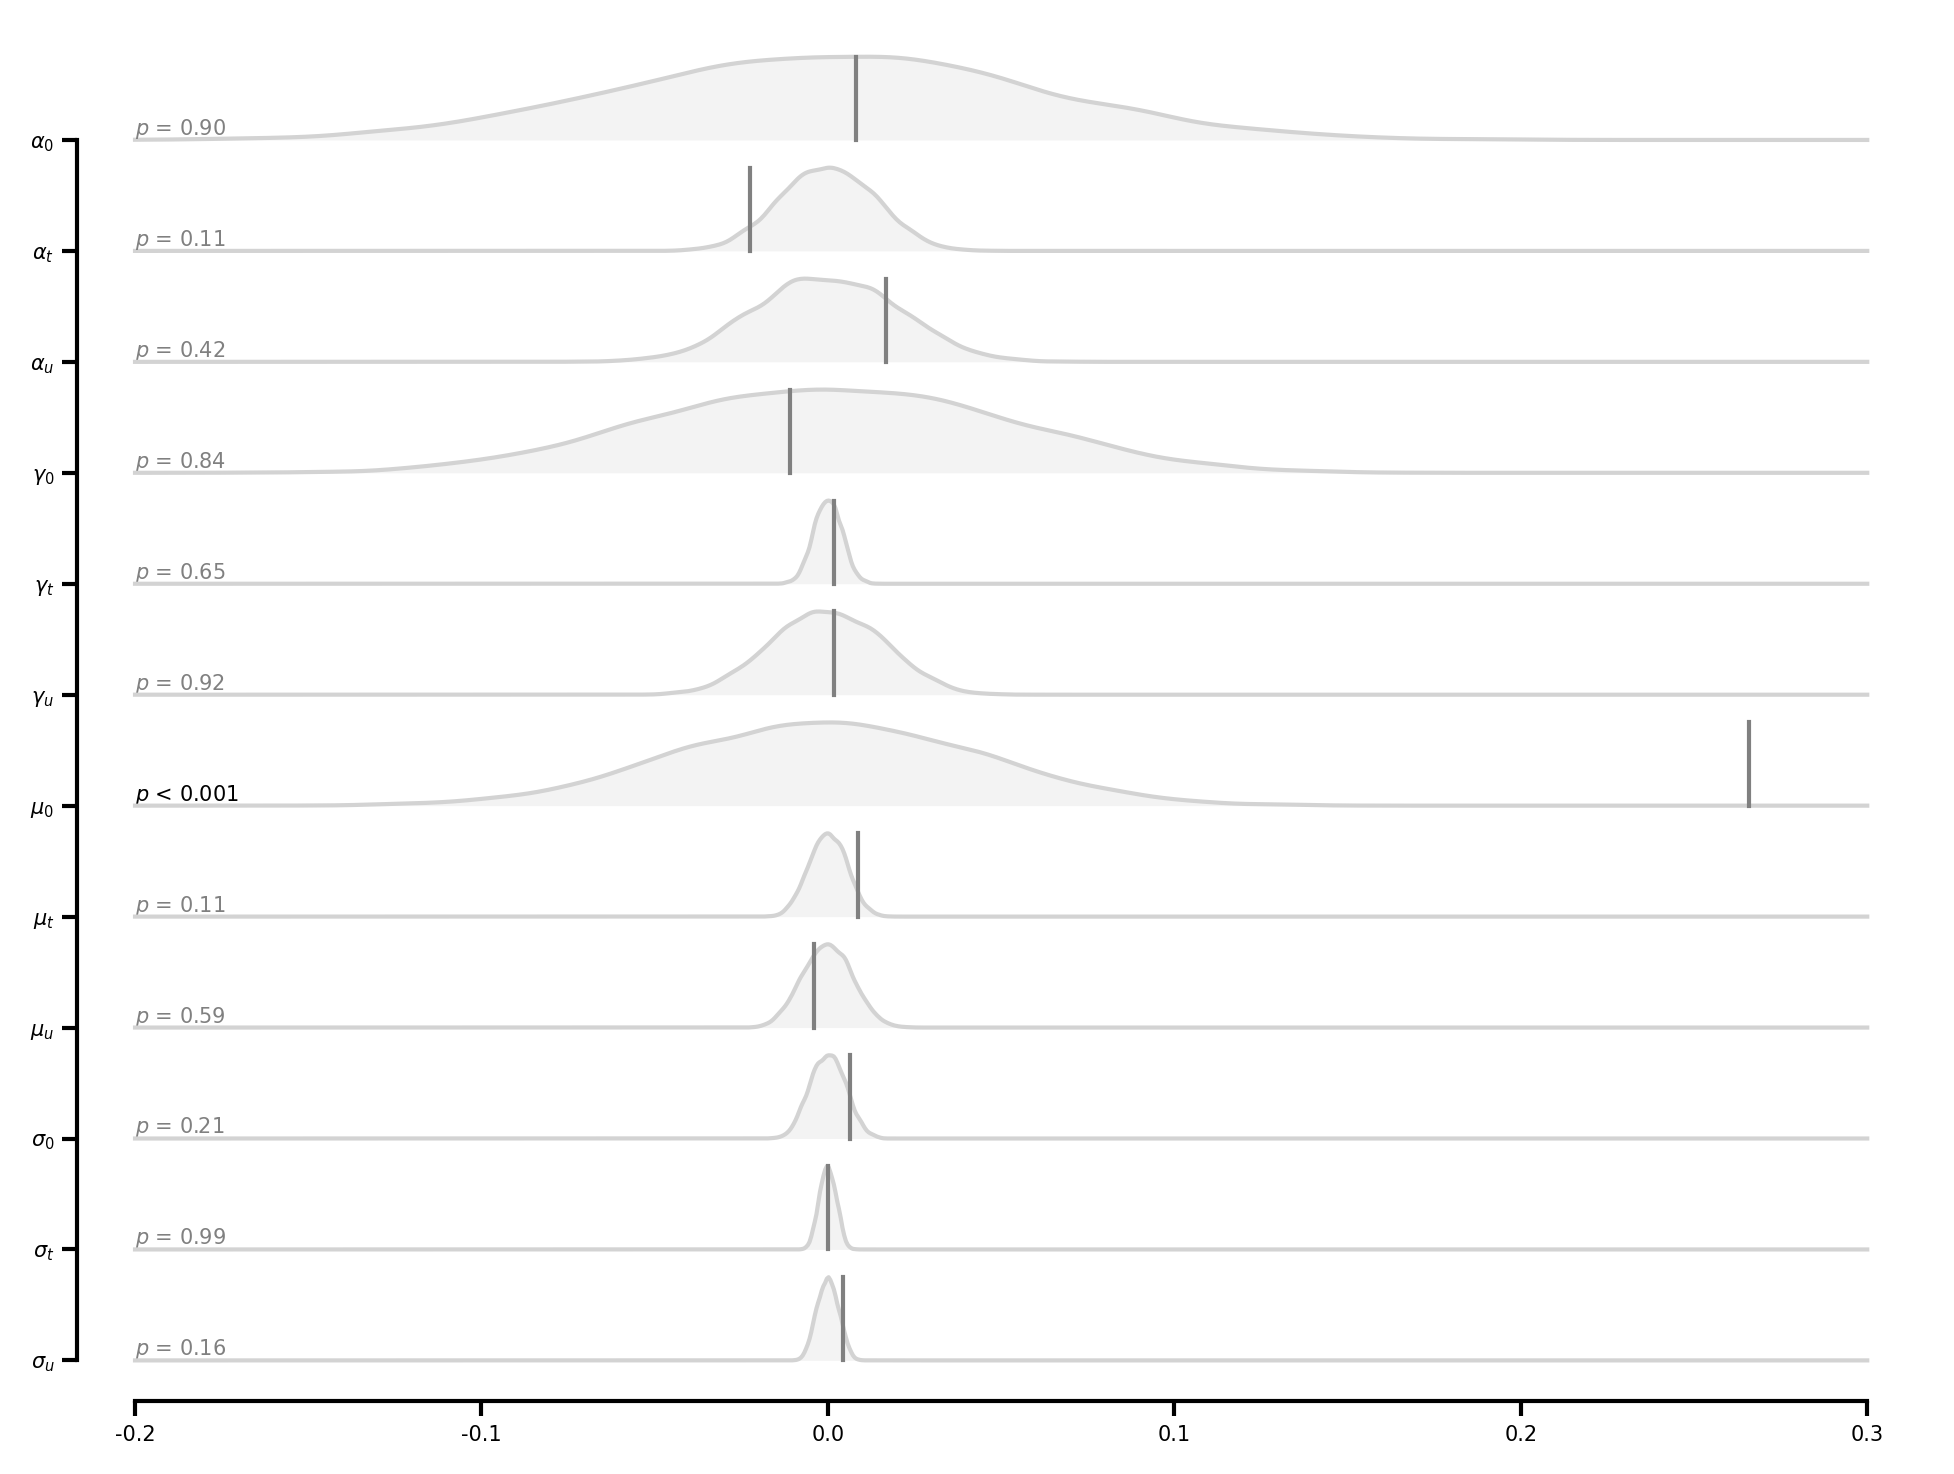

In [25]:
from scipy.stats.kde import gaussian_kde
def ridgeline(data, observed_vals=None, pvals=None, overlap=0, labels=None, n_points=1000, x_ticks=None, ax=None, show_zero=False, ylabel=None, xlabel=None):
    """
    ridgeline plot from https://glowingpython.blogspot.com/2020/03/ridgeline-plots-in-pure-matplotlib.html
    """

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    if overlap > 1 or overlap < 0:
        raise ValueError('overlap must be in [0 1]')

    if x_ticks is not None:
        xx = np.linspace(x_ticks[0], x_ticks[-1], n_points)
    else:
        xx = np.linspace(np.min(np.concatenate(data)),
                        np.max(np.concatenate(data)), n_points)

    ys = []
    for i, (d, o, p) in enumerate(zip(data, observed_vals, pvals)):
        pdf = gaussian_kde(d)
        y = i*(1.0-overlap)
        ys.append(y)
        curve = pdf(xx)

        curve = (curve / curve.max()) * 0.75

        ax.fill_between(xx, np.ones(n_points)*y, 
                            curve+y, zorder=len(data)-i+1, color='lightgray', alpha=0.25, lw=0)

        x_peak_value = xx[np.argmax(curve)]
        y_peak_value = y + curve.max()
        ax.plot(xx, curve+y, c='lightgray', zorder=len(data)-i+1)


        if show_zero:
            # bracket(ax, 0, 1, [0, x_peak_value], [y_peak_value, y_peak_value], dh=curve.max()/10, barh=curve.max()/10)
            ax.plot([0, 0], [y, y_peak_value], color='gray', linestyle='--', zorder=len(data)-i+1)

        else:
            # bracket(ax, 0, 1, [o, x_peak_value], [y_peak_value, y_peak_value], dh=curve.max()/10, barh=curve.max()/10)
            
            if o is not None:
                ax.plot([o, o], [y, y_peak_value], color='gray', linestyle='-', zorder=len(data)-i+1)

            
        color_s = 'gray' if p > 0.05 else 'k'
        ax.annotate(f"{stars(p)}",  # \nCI: [{lb_slope:.2f}, {ub_slope:.2f}]",
                    xy=(xx[0], y), xycoords='data',
                    fontsize=5, ha='left', va='bottom', color=color_s)

    if labels is not None:
        if len(labels) != len(data):
            raise ValueError('labels must be the same length as data')
        if len(ys) != len(labels):
            raise ValueError('ys must be the same length as labels')
        ax.set_yticks(ys)
        ax.set_ylim([0, y])
        ax.set_yticklabels(labels)
    
    if x_ticks is not None:
        ax.set_xlim([x_ticks[0], x_ticks[1]])
        ax.set_xticks(x_ticks)
    
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    space_axes(ax, top_y=1/y)

fig, ax = plt.subplots(1, 1)
data, obs_vals, pvals = dist_shuffled_slopes, dist_observed_slope, dist_p_value_slope
ridgeline(data, observed_vals=obs_vals, pvals=pvals, overlap=.0, ax=ax, labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3])

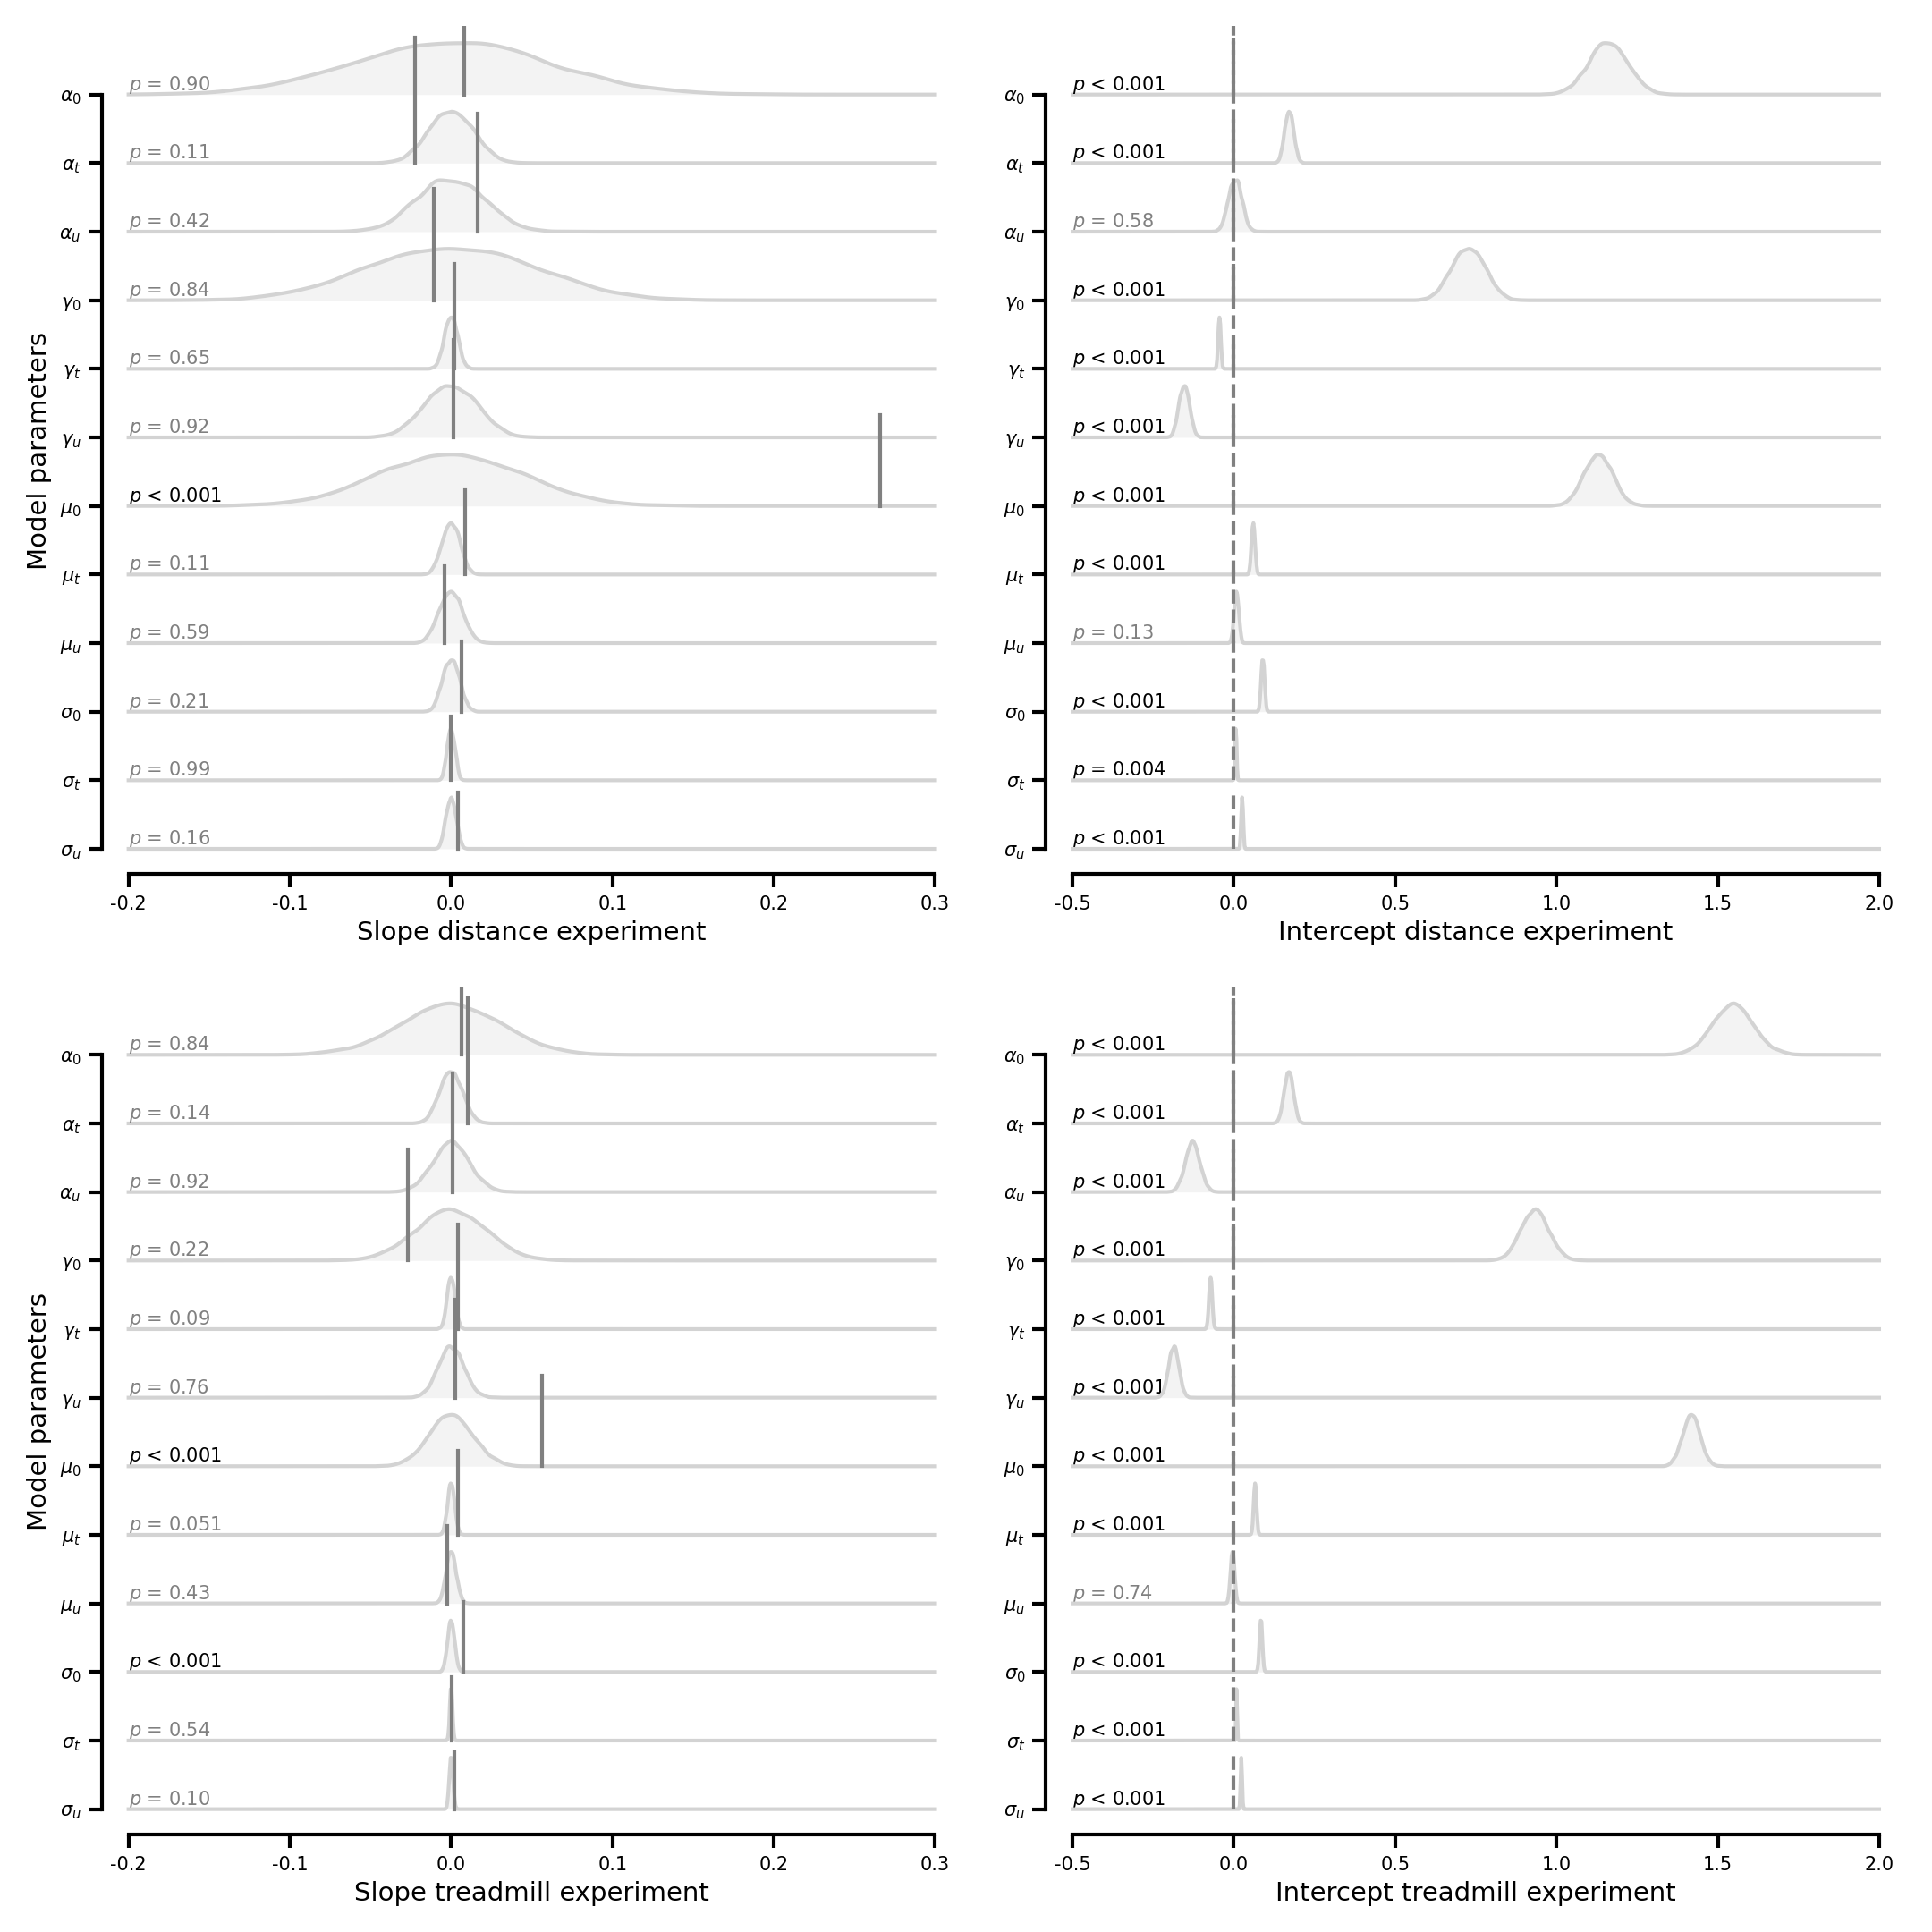

In [22]:

fig, axs = plt.subplots(2, 2, figsize=(cm2inch(18), cm2inch(18)))
ridgeline(dist_shuffled_slopes, observed_vals=dist_observed_slope, pvals=dist_p_value_slope, overlap=.0, ax=axs[0, 0], labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel='Slope distance experiment')
ridgeline(dist_shuffled_intercepts, observed_vals=dist_observed_intercept, pvals=dist_p_value_intercept, overlap=.0, ax=axs[0, 1], labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel='Intercept distance experiment')
ridgeline(tm_shuffled_slopes, observed_vals=tm_observed_slope, pvals=tm_p_value_slope, overlap=.0, ax=axs[1, 0], labels=names, x_ticks=[-0.2, -0.1, 0, 0.1, 0.2, 0.3], ylabel='Model parameters', xlabel='Slope treadmill experiment')
ridgeline(tm_shuffled_intercepts, observed_vals=tm_observed_intercept, pvals=tm_p_value_intercept, overlap=.0, ax=axs[1, 1], labels=names, x_ticks=[-0.5, 0, 0.5, 1, 1.5, 2], show_zero=True, xlabel='Intercept treadmill experiment')



# Figure 3: Dynamics of decision parameters across action costs.

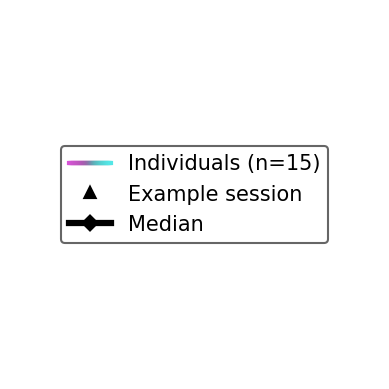

In [11]:

def dummy_legend(ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    ex_session = ax.plot(2, 0, color='black', marker='^', zorder=10, markersize=2, linewidth=0, label='Example session')
    median = ax.plot([-100, -101], [-100, -101], color='k', marker='D', markersize=2, linestyle='-', lw=1.5, label=f'Median', zorder=5)

    ax.axis('off')
    ax.set_xlim(10, 11)
    ax.set_ylim(10, 11)

    add_colored_intact(ax, handles=[ex_session, median],
                    labels=['Example session', 'Median'], text=f'Individuals (n={len(animalList)})', 
                    loc='center', bbox=(.5, .5))


fig, axs = plt.subplots(1, 1, figsize=(cm2inch(3), cm2inch(3)))
dummy_legend(ax=axs)

NameError: name 'Figure3B_zero' is not defined

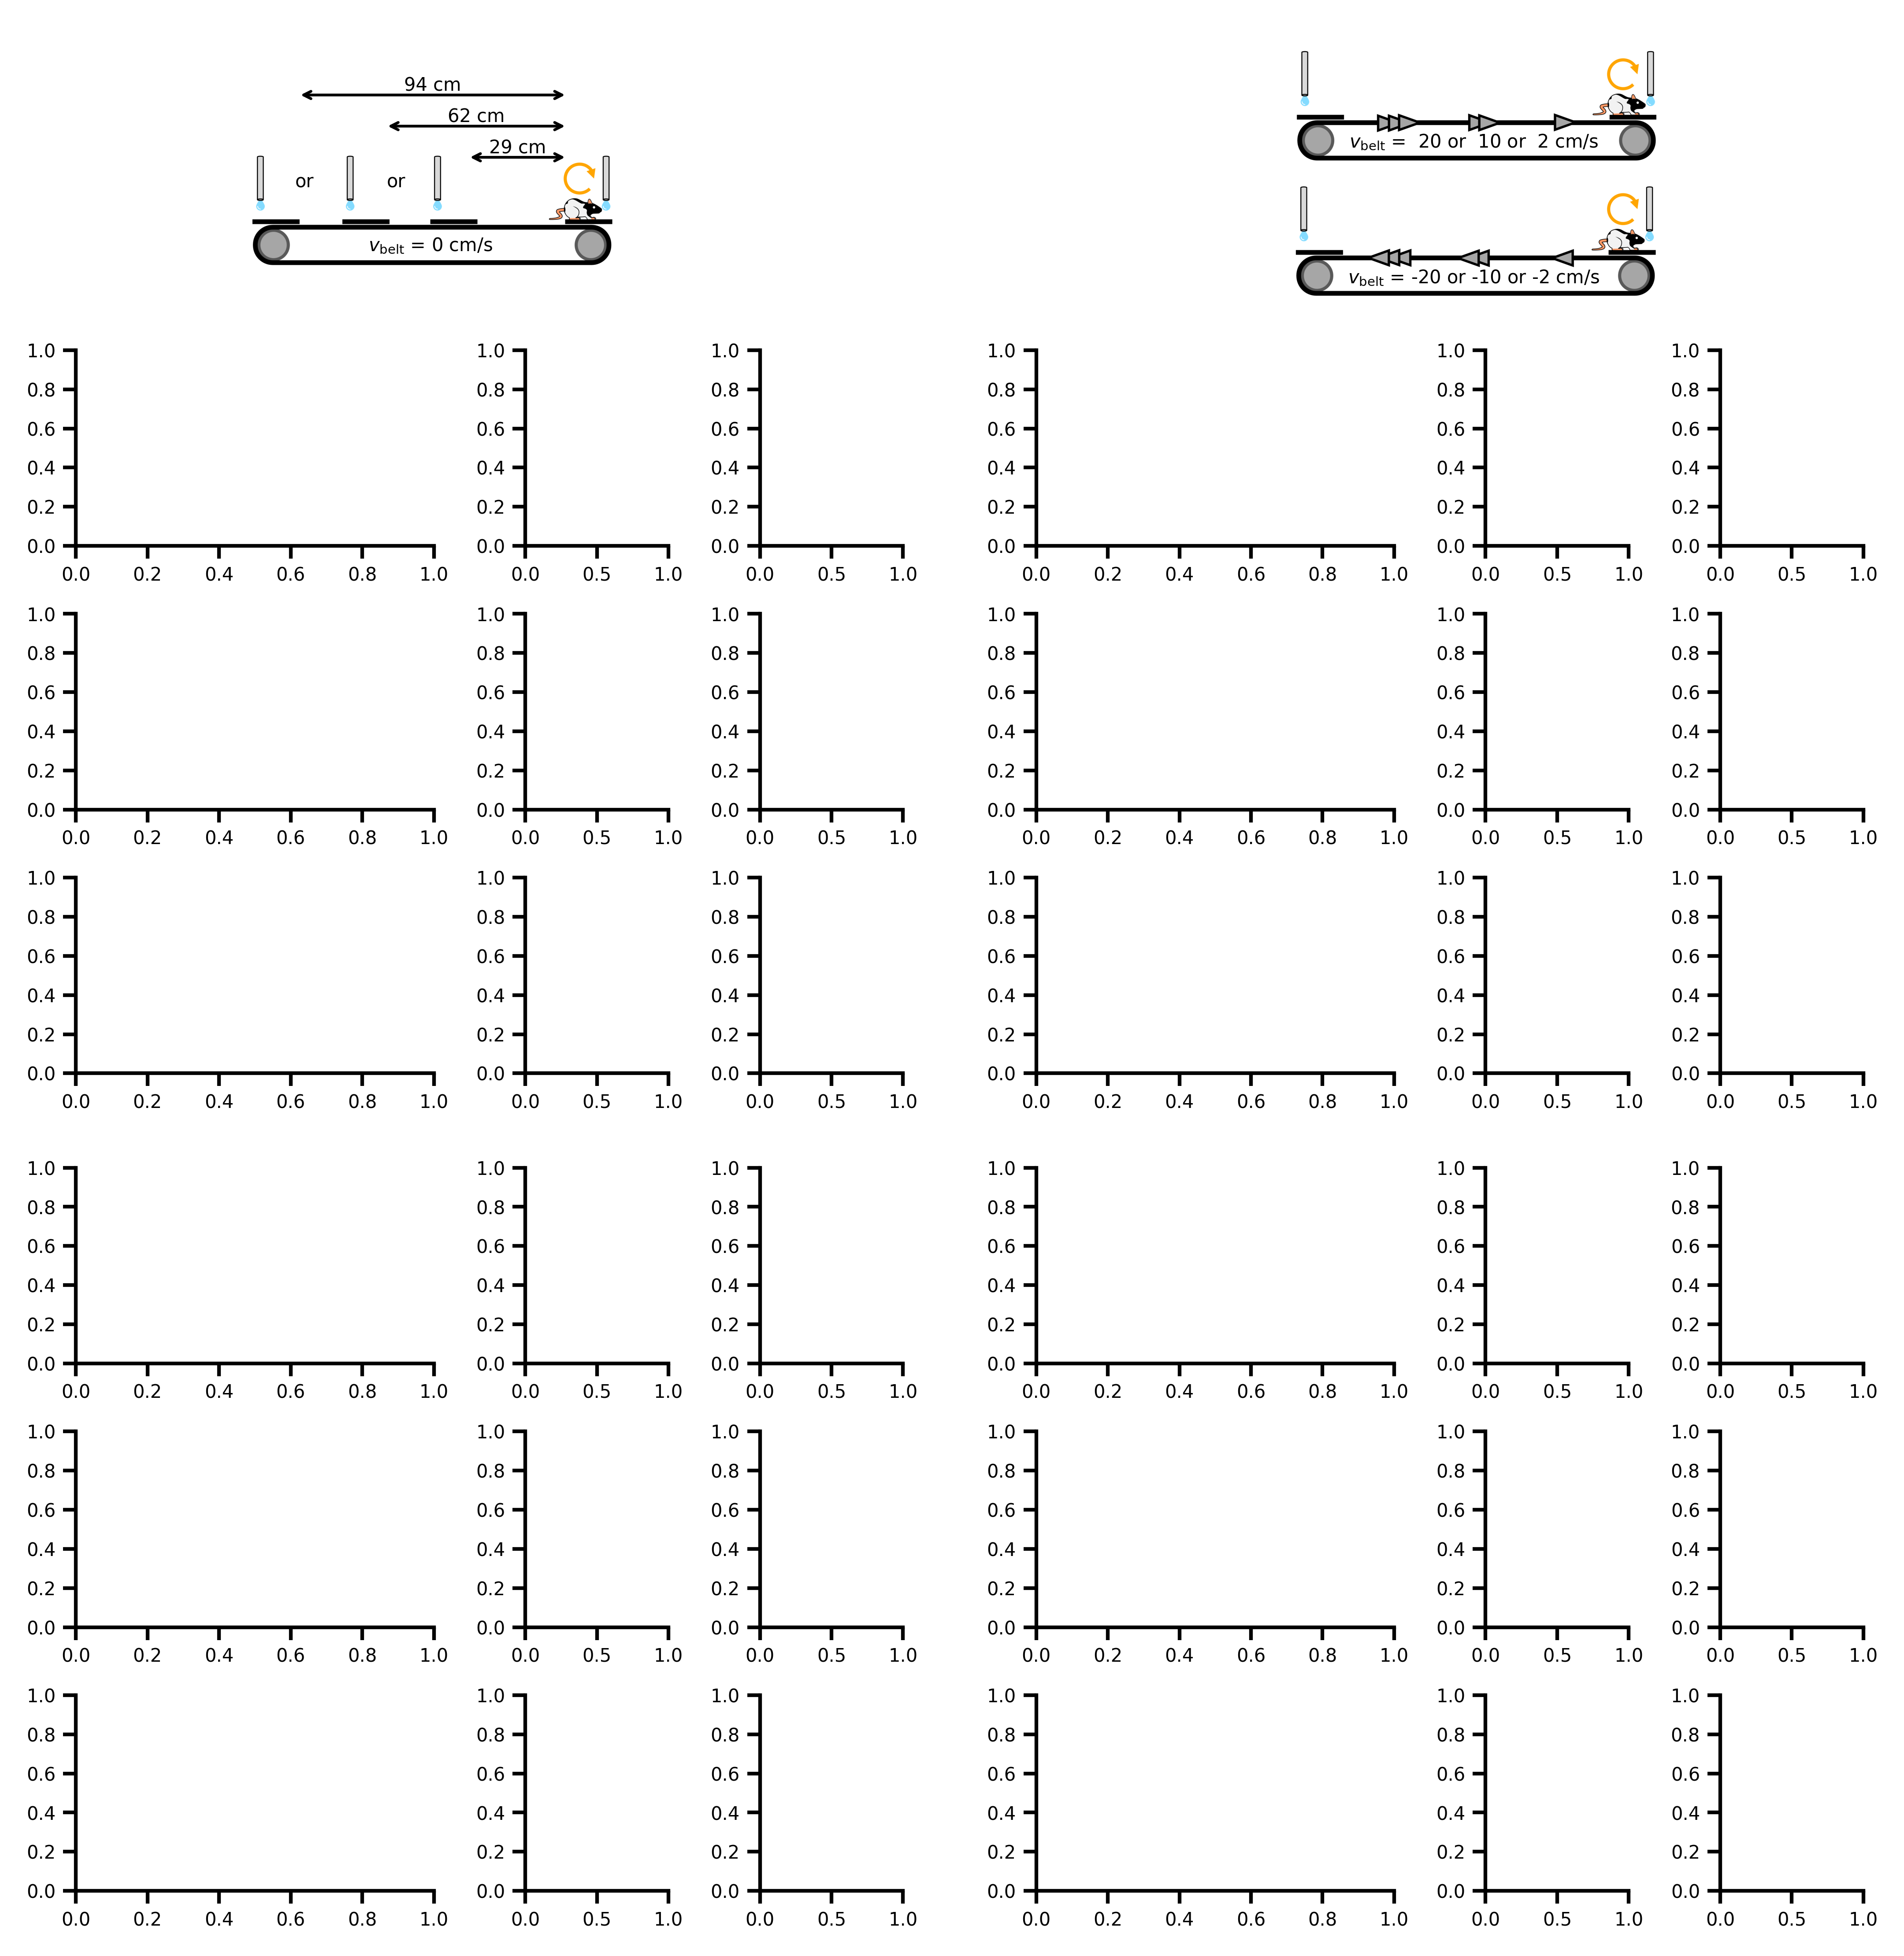

In [12]:

fig = plt.figure(figsize=(cm2inch(18), cm2inch(18.5)),
                 constrained_layout=True, facecolor='w', dpi=600)

gs0 = fig.add_gridspec(8, 1, height_ratios=[1.2, 1, 1, 1, .1, 1, 1, 1])

row1 = gs0[0].subgridspec(1, 3, wspace=.5, hspace=.5, width_ratios=[1, .2, 1])
distance_schematic = plt.subplot(row1[0])
vbelt_schematic = plt.subplot(row1[2])

row2 = gs0[1].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_0_distance = plt.subplot(row2[0])
fit_alpha_0_distance_slope = plt.subplot(row2[1])
fit_alpha_0_distance_intercept = plt.subplot(row2[2])
fit_alpha_0_vbelt = plt.subplot(row2[4])
fit_alpha_0_vbelt_slope = plt.subplot(row2[5])
fit_alpha_0_vbelt_intercept = plt.subplot(row2[6])

row3 = gs0[2].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_t_distance = plt.subplot(row3[0])
fit_alpha_t_distance_slope = plt.subplot(row3[1])
fit_alpha_t_distance_intercept = plt.subplot(row3[2])
fit_alpha_t_vbelt = plt.subplot(row3[4])
fit_alpha_t_vbelt_slope = plt.subplot(row3[5])
fit_alpha_t_vbelt_intercept = plt.subplot(row3[6])

row4 = gs0[3].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_alpha_u_distance = plt.subplot(row4[0])
fit_alpha_u_distance_slope = plt.subplot(row4[1])
fit_alpha_u_distance_intercept = plt.subplot(row4[2])
fit_alpha_u_vbelt = plt.subplot(row4[4])
fit_alpha_u_vbelt_slope = plt.subplot(row4[5])
fit_alpha_u_vbelt_intercept = plt.subplot(row4[6])

row5 = gs0[5].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_0_distance = plt.subplot(row5[0])
fit_gamma_0_distance_slope = plt.subplot(row5[1])
fit_gamma_0_distance_intercept = plt.subplot(row5[2])
fit_gamma_0_vbelt = plt.subplot(row5[4])
fit_gamma_0_vbelt_slope = plt.subplot(row5[5])
fit_gamma_0_vbelt_intercept = plt.subplot(row5[6])

row6 = gs0[6].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_t_distance = plt.subplot(row6[0])
fit_gamma_t_distance_slope = plt.subplot(row6[1])
fit_gamma_t_distance_intercept = plt.subplot(row6[2])
fit_gamma_t_vbelt = plt.subplot(row6[4])
fit_gamma_t_vbelt_slope = plt.subplot(row6[5])
fit_gamma_t_vbelt_intercept = plt.subplot(row6[6])

row7 = gs0[7].subgridspec(1, 7, wspace=.5, hspace=.5, width_ratios=[2.5, 1, 1, .1, 2.5, 1, 1])
fit_gamma_u_distance = plt.subplot(row7[0])
fit_gamma_u_distance_slope = plt.subplot(row7[1])
fit_gamma_u_distance_intercept = plt.subplot(row7[2])
fit_gamma_u_vbelt = plt.subplot(row7[4])
fit_gamma_u_vbelt_slope = plt.subplot(row7[5])
fit_gamma_u_vbelt_intercept = plt.subplot(row7[6])




Figure3A(ax=distance_schematic)
Figure3D(ax=vbelt_schematic)

Figure3B_zero(ax=fit_alpha_0_distance)
Figure3B_t(ax=fit_alpha_t_distance)
Figure3B_u(ax=fit_alpha_u_distance, show_xlabel=True)
Figure3C_zero(ax=fit_gamma_0_distance)
Figure3C_t(ax=fit_gamma_t_distance)
Figure3C_u(ax=fit_gamma_u_distance, show_xlabel=True)

Figure3B_zero_stats(ax_slope=fit_alpha_0_distance_slope, ax_intercept=fit_alpha_0_distance_intercept)
Figure3B_t_stats(ax_slope=fit_alpha_t_distance_slope, ax_intercept=fit_alpha_t_distance_intercept)
Figure3B_u_stats(ax_slope=fit_alpha_u_distance_slope, ax_intercept=fit_alpha_u_distance_intercept)
Figure3C_zero_stats(ax_slope=fit_gamma_0_distance_slope, ax_intercept=fit_gamma_0_distance_intercept)
Figure3C_t_stats(ax_slope=fit_gamma_t_distance_slope, ax_intercept=fit_gamma_t_distance_intercept)
Figure3C_u_stats(ax_slope=fit_gamma_u_distance_slope, ax_intercept=fit_gamma_u_distance_intercept)


Figure3E_zero(ax=fit_alpha_0_vbelt)
Figure3E_t(ax=fit_alpha_t_vbelt)
Figure3E_u(ax=fit_alpha_u_vbelt, show_xlabel=True)
Figure3F_zero(ax=fit_gamma_0_vbelt)
Figure3F_t(ax=fit_gamma_t_vbelt)
Figure3F_u(ax=fit_gamma_u_vbelt, show_xlabel=True)

Figure3E_zero_stats(ax_slope=fit_alpha_0_vbelt_slope, ax_intercept=fit_alpha_0_vbelt_intercept)
Figure3E_t_stats(ax_slope=fit_alpha_t_vbelt_slope, ax_intercept=fit_alpha_t_vbelt_intercept)
Figure3E_u_stats(ax_slope=fit_alpha_u_vbelt_slope, ax_intercept=fit_alpha_u_vbelt_intercept)
Figure3F_zero_stats(ax_slope=fit_gamma_0_vbelt_slope, ax_intercept=fit_gamma_0_vbelt_intercept)
Figure3F_t_stats(ax_slope=fit_gamma_t_vbelt_slope, ax_intercept=fit_gamma_t_vbelt_intercept)
Figure3F_u_stats(ax_slope=fit_gamma_u_vbelt_slope, ax_intercept=fit_gamma_u_vbelt_intercept)

axes = fig.get_axes()
for ax in axes:
    ax.yaxis.set_major_formatter('{x:>5.2f}')


legend = fig.add_axes([.5, .92, .01, .01])
dummy_legend(ax=legend)

figuresLabels={"A":[0.105, .96], "D":[0.65, .96], 
               "B":[0.0, .835], "E":[0.515, .835],
               "C":[0.0, .415], "F":[0.515, .415],
               }

for label,coordinates in sorted(figuresLabels.items()):
    fig.text(coordinates[0], coordinates[1],
             label, figure=fig, 
             weight='bold', fontsize=7, ha='left', va='bottom')

# plt.savefig("./Figures_paper/Figure_3.pdf", facecolor='w', 
#         edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)
# plt.savefig("./Figures_paper/Figure_3.svg", facecolor='w', 
#         edgecolor='none', bbox_inches='tight', format="svg", dpi=600)